In [1]:
options(warn = -1)
suppressMessages(require(Seurat))
suppressMessages(require(ggplot2))
suppressMessages(require(dplyr))
suppressMessages(require(reticulate))
suppressMessages(require(stringr))
suppressMessages(require(ggpubr))
suppressMessages(require(tidydr))
suppressMessages(require(CellTrek))
suppressMessages(require(CARD))
suppressMessages(require(monocle))
suppressMessages(require(viridis))
devtools::load_all('../Cell2Spatial/')

ℹ Loading Cell2Spatial


In [2]:
source('modules/globalParams.R')
source('modules/utils.R')
source('modules/vis.R')
source('modules/reformatProjRes.R')

In [3]:
out.figs.dir <- '../2.results/TLS/figs'
out.data.dir <- '../2.results/TLS/data'

In [4]:
dir.create(out.figs.dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out.data.dir, showWarnings = FALSE, recursive = TRUE)

In [5]:
MTH_COLOR <- c(
    'Reference'    = 'grey',
    'Cell2Spatial' = '#F7B263',
    'CytoSPACE' = '#D6AA8E',
    'CellTrek' = '#99C0CC',
    'Tangram' = 'lightgreen',
    'Seurat' = '#CC00FF'
)

### Loading kidney ST and SC datasets 

- GSM5924038
- GSM5924053

In [6]:
brain.st <- readRDS('../0.data/TLS/TLS_SP.RDS')[['GSM5924038']]

In [7]:
brain.sc <- readRDS('../0.data/TLS/TICAtlas_downsampled_1000.rds')

In [8]:
brain.st

An object of class Seurat 
17943 features across 3206 samples within 1 assay 
Active assay: Spatial (17943 features, 0 variable features)
 2 layers present: counts, data
 1 image present: slice1

In [9]:
brain.sc

An object of class Seurat 
92265 features across 24834 samples within 2 assays 
Active assay: RNA (87659 features, 0 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: integrated
 2 dimensional reductions calculated: pca, umap

In [358]:
brain.st <- brain.st %>% SCTransform(., verbose = FALSE, assay = 'Spatial') %>%
    RunPCA(verbose = FALSE) %>%
    RunUMAP(dims = 1 : 30, verbose = FALSE) %>%
    FindNeighbors(., dims = 1:30, verbose = FALSE, res = 0.8) %>%
    FindClusters(., verbose = FALSE)

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’



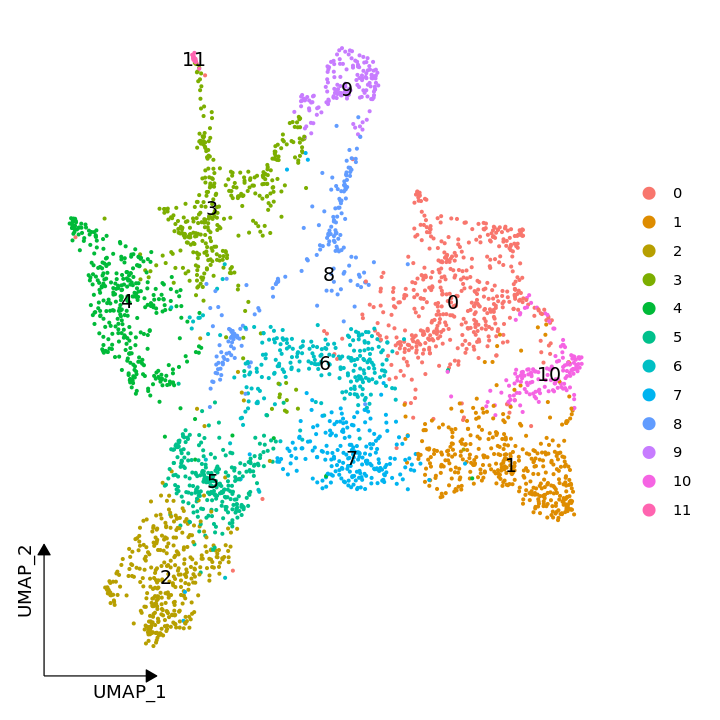

In [359]:
options(repr.plot.width = 6, repr.plot.height = 6)
DimPlot(brain.st, reduction = "umap", label = TRUE) + theme_dr(xlength = 0.2, ylength = 0.2, arrow = grid::arrow(length = unit(0.1, "inches"), ends = 'last', type = "closed")) + theme(panel.grid = element_blank())
ggsave(file.path(out.figs.dir, 'TLS.ST.cluster.UMAP.dimplot.pdf'), width = 6, height = 6)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


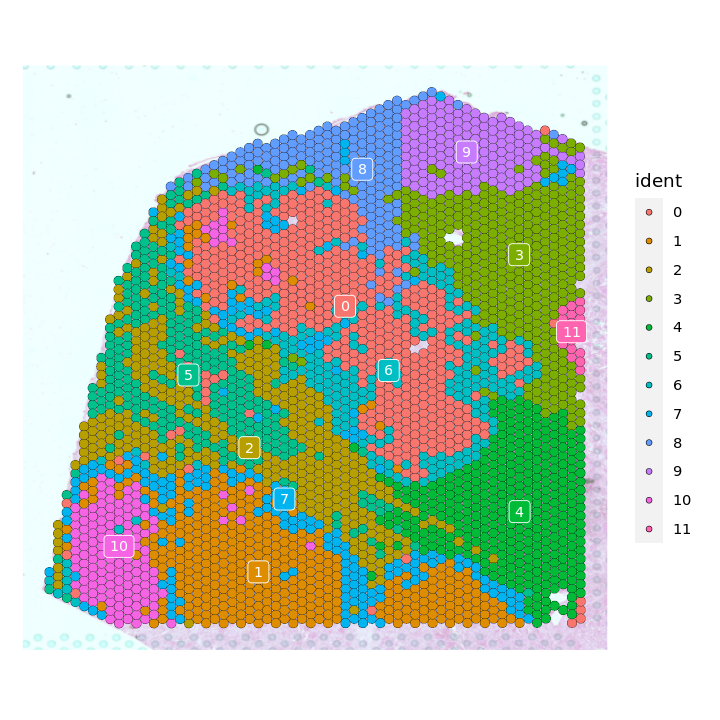

In [360]:
options(repr.plot.width = 6, repr.plot.height = 6)
SpatialDimPlot(brain.st, label = TRUE, label.size = 3, image.alpha = 0.5)
ggsave(file.path(out.figs.dir, 'brain.ST.cluster.UMAP.spatial.pdf'), width = 6, height = 6)

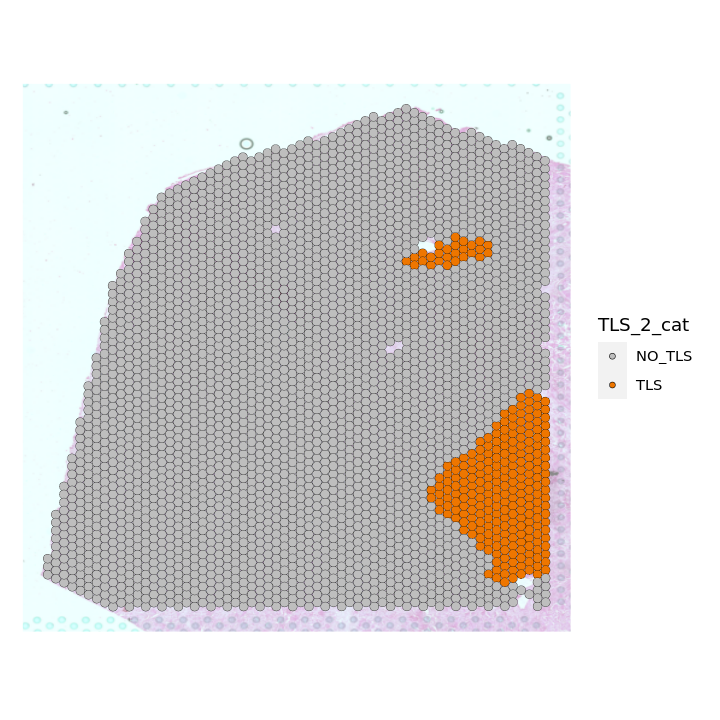

In [361]:
options(repr.plot.width = 6, repr.plot.height = 6)
SpatialDimPlot(brain.st, label = FALSE, label.size = 3, image.alpha = 0.5, group.by = 'TLS_2_cat', cols = c('NO_TLS' = 'grey', 'TLS' = 'darkorange2'))
ggsave(file.path(out.figs.dir, 'brain.ST.TLS.UMAP.spatial.pdf'), width = 6, height = 6)

In [362]:
f.ctypes <- levels(brain.st)
gps <- lapply(f.ctypes, function(ct) {
    h.cells <- subset(brain.st, idents = ct) %>% Cells
    SpatialPlot(brain.st, cells.highlight = h.cells) + NoLegend() + ggtitle(ct) 
})

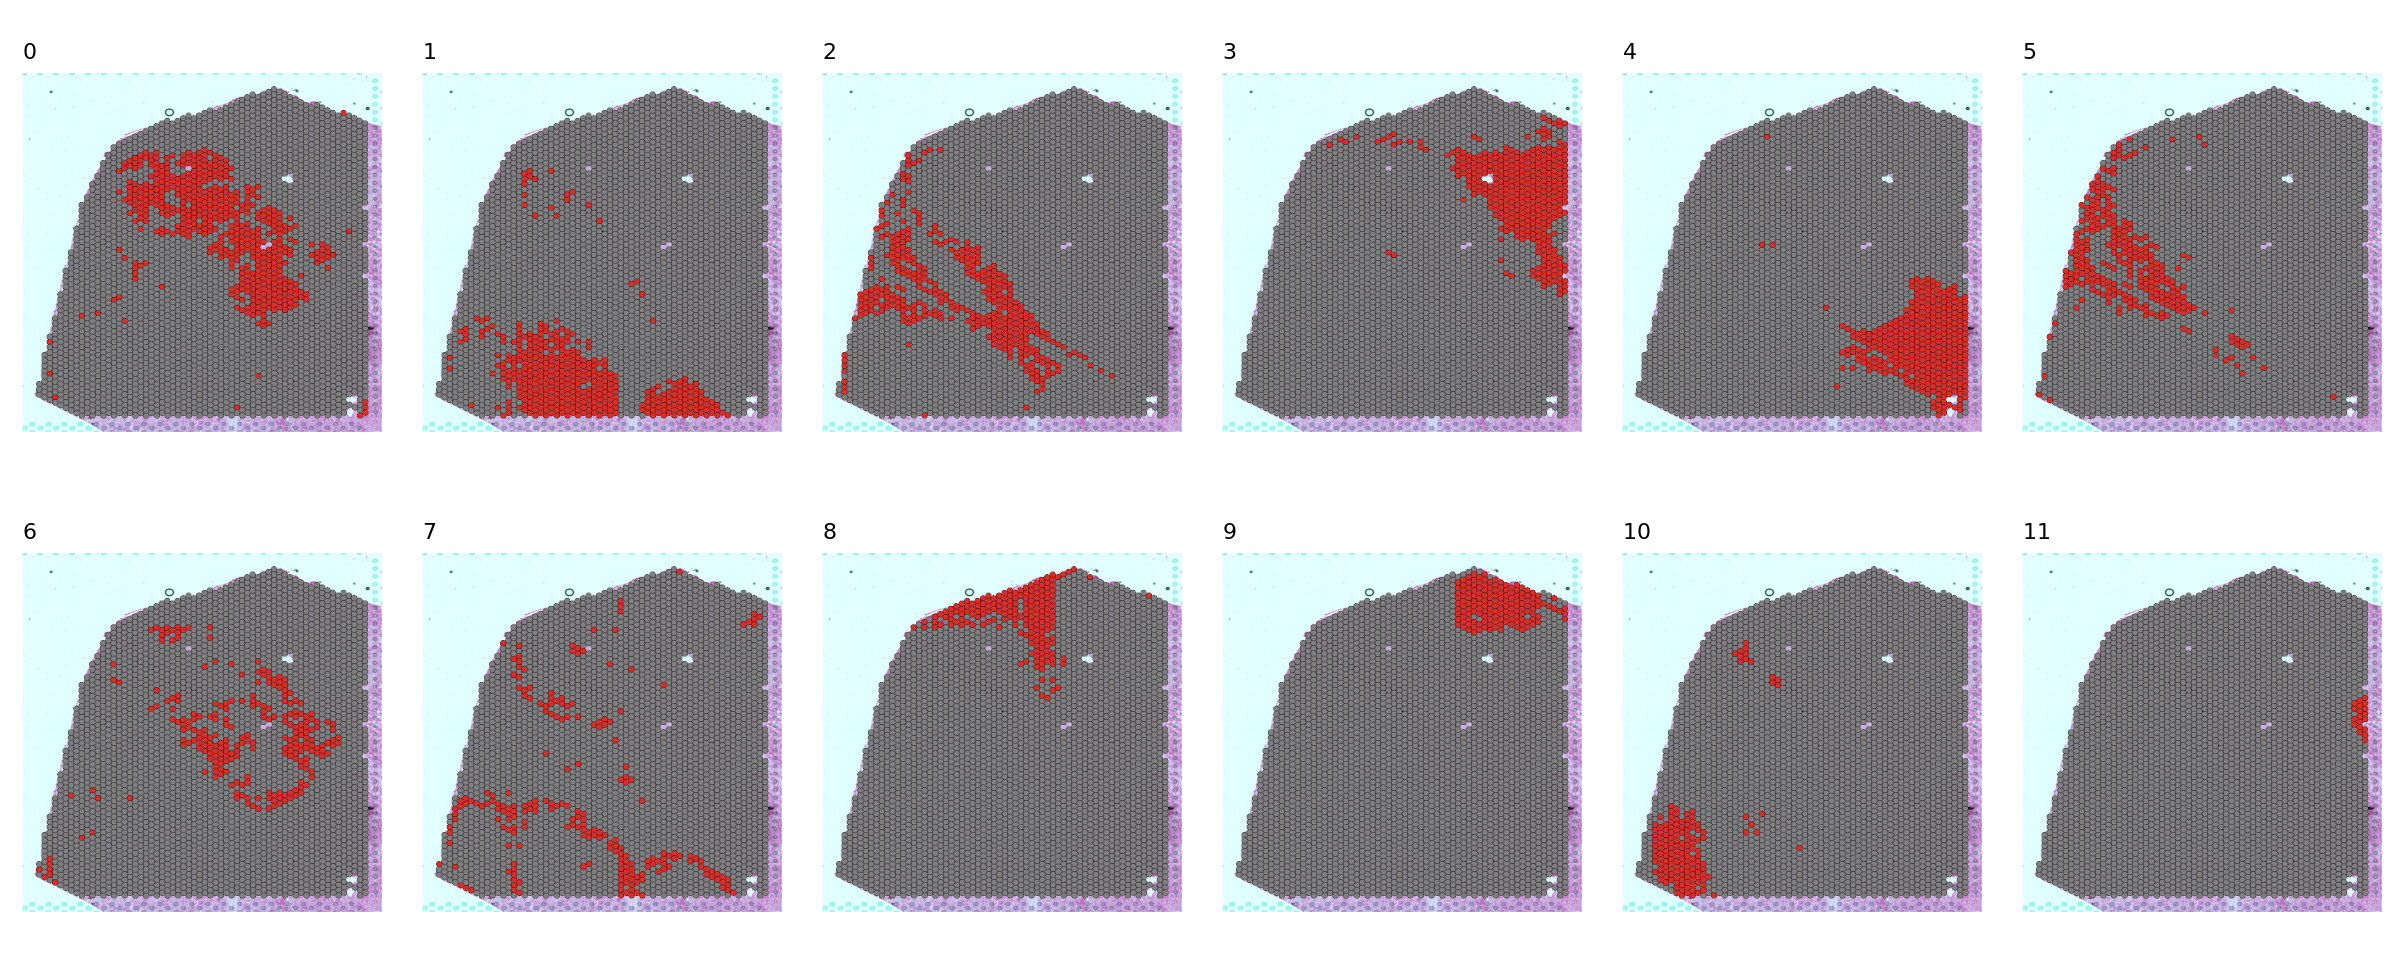

In [363]:
options(repr.plot.width = 20, repr.plot.height = 8)
ggarrange(plotlist = gps, nrow = 2, ncol = 6)

ggsave(file.path(out.figs.dir, 'brain.ST.UMAP.split.spatial.pdf'), width = 20, height = 8)

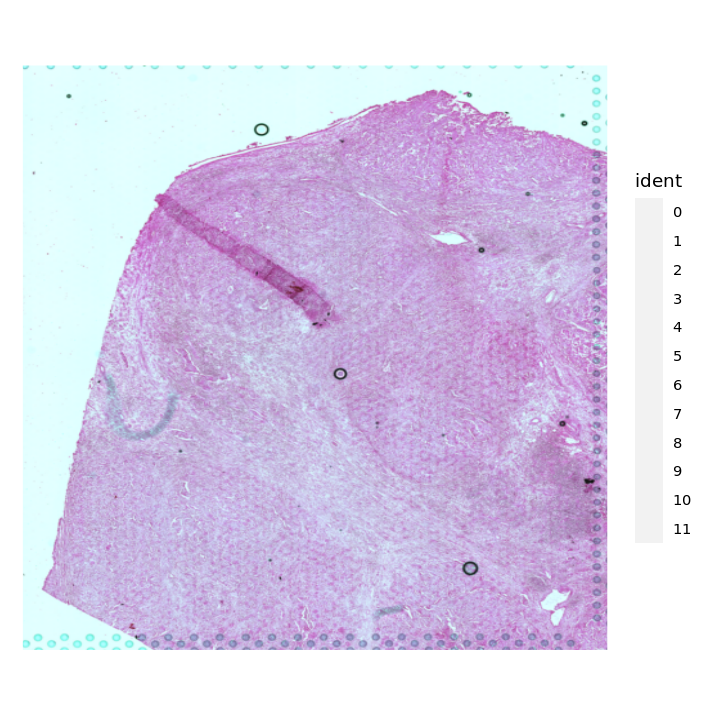

In [364]:
options(repr.plot.width = 6, repr.plot.height = 6)
SpatialDimPlot(brain.st, label = FALSE, label.size = 3,, alpha = 0)
ggsave(file.path(out.figs.dir, 'brain.ST.Image.spatial.pdf'), width = 6, height = 6)

In [365]:
tls.genes <- read.table('tls.genes.txt')[, 1]

In [366]:
tls.genes2 <- c('CCR6', 'CD1D', 'CD79B', 'CETP', 'EIF1AY', 'LAT', 'PTGDS', 'RBP5', 'SKAP1')

In [367]:
brain.st <- AddModuleScore(brain.st, features = list(xx = tls.genes))

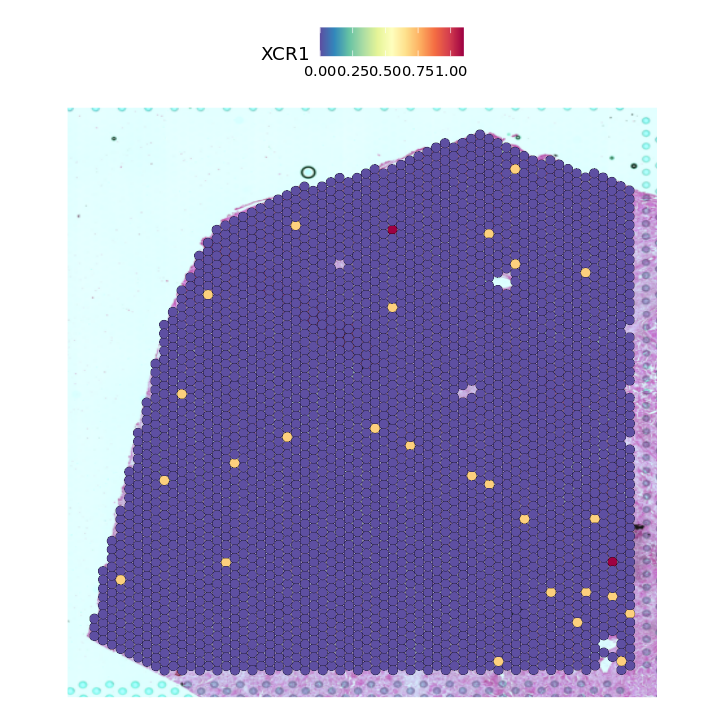

In [419]:
options(repr.plot.width = 6, repr.plot.height = 6)
SpatialFeaturePlot(brain.st, features = 'XCR1')

In [369]:
options(repr.plot.width = 1.5, repr.plot.height = 5)
pheatmap::pheatmap(
    data.frame(table(brain.st$seurat_clusters, brain.st$TLS_2_cat)[, 2]), 
    cluster_cols = F, 
    cluster_rows = F, 
    show_colnames = F,
    color = hcl.colors(50, "BluYl"),
    width = 1.2, 
    height = 5,
    filename = file.path(out.figs.dir, 'tls.heatmap.pdf')
)

In [370]:
brain.sc@meta.data %>% head

,orig.ident,nCount_RNA,nFeature_RNA,patient,percent.mt,gender,source,subtype,cluster_kmeans_k6,cell_type
,<fct>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<fct>
X121270372616437_1_1_1_1,SeuratProject,267.4,199,BC_1,16.043381,female,breast,BC,1,Mast cells
X121347516295582_1_1_1_1,SeuratProject,172.1,147,BC_1,13.364323,female,breast,BC,1,Recently activated CD4 T cells
X126279350400925_1_1_1_1,SeuratProject,179.6,125,BC_1,16.035635,female,breast,BC,1,Mast cells
X130075864524517_1_1_1_1,SeuratProject,618.2,397,BC_1,8.882429,female,breast,BC,1,mDC
X130211034609580_1_1_1_1,SeuratProject,328.4,257,BC_1,7.490865,female,breast,BC,1,Naive-memory CD4 T cells
X134607992670070_1_1_1_1,SeuratProject,374.3,251,BC_1,13.625434,female,breast,BC,1,Naive-memory CD4 T cells


In [371]:
Idents(brain.sc) <- brain.sc$cell_type

In [372]:
brain.sc <- SCTransform(brain.sc, ncells = 3000, verbose = FALSE) %>%
    RunPCA(verbose = FALSE) %>%
    RunUMAP(dims = 1 : 30, verbose = FALSE)

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’



In [373]:
brain.sc@meta.data %>% head

,orig.ident,nCount_RNA,nFeature_RNA,patient,percent.mt,gender,source,subtype,cluster_kmeans_k6,cell_type,nCount_SCT,nFeature_SCT
,<fct>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<int>
X121270372616437_1_1_1_1,SeuratProject,267.4,199,BC_1,16.043381,female,breast,BC,1,Mast cells,1629,459
X121347516295582_1_1_1_1,SeuratProject,172.1,147,BC_1,13.364323,female,breast,BC,1,Recently activated CD4 T cells,1512,504
X126279350400925_1_1_1_1,SeuratProject,179.6,125,BC_1,16.035635,female,breast,BC,1,Mast cells,1555,479
X130075864524517_1_1_1_1,SeuratProject,618.2,397,BC_1,8.882429,female,breast,BC,1,mDC,1930,443
X130211034609580_1_1_1_1,SeuratProject,328.4,257,BC_1,7.490865,female,breast,BC,1,Naive-memory CD4 T cells,1700,463
X134607992670070_1_1_1_1,SeuratProject,374.3,251,BC_1,13.625434,female,breast,BC,1,Naive-memory CD4 T cells,1725,432


In [374]:
set.seed(2023063) 
cell.colors <- randomcoloR::distinctColorPalette(length(unique(brain.sc$cell_type )))  %>% `names<-`(unique(brain.sc$cell_type))

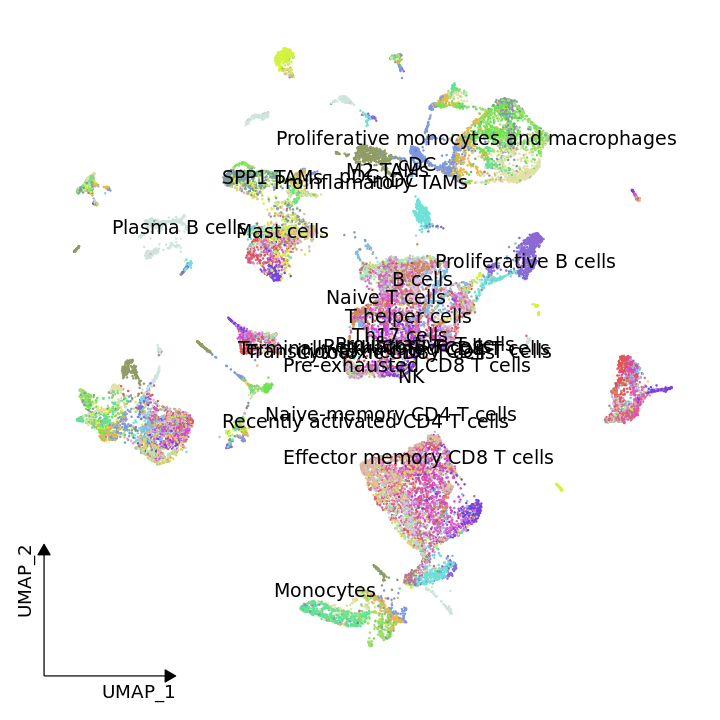

In [375]:
options(repr.plot.width = 6, repr.plot.height = 6)
DimPlot(brain.sc, label = TRUE, cols = cell.colors) + theme_dr(xlength = 0.2, ylength = 0.2, arrow = grid::arrow(length = unit(0.1, "inches"), ends = 'last', type = "closed")) + theme(panel.grid = element_blank()) + NoLegend()
ggsave(file.path(out.figs.dir, 'brain.SC.cluster.UMAP.dimplot.pdf'), width = 6, height = 6)

In [376]:
table(brain.sc$cell_type)


                                B cells                   Proliferative B cells 
                                   1000                                     834 
                         Plasma B cells                           Naive T cells 
                                   1000                                    1000 
                     Regulatory T cells                          T helper cells 
                                   1000                                    1000 
                             Th17 cells                   Proliferative T cells 
                                   1000                                    1000 
         Recently activated CD4 T cells                Naive-memory CD4 T cells 
                                   1000                                    1000 
        Transitional memory CD4 T cells               Pre-exhausted CD8 T cells 
                                   1000                                    1000 
                  Cytotoxic

In [377]:
brain.sc$mainType <- as.vector(brain.sc$cell_type)
brain.sc$mainType[brain.sc$mainType %in% c('B cells', 'Proliferative B cells', 'Plasma B cells')] <- 'B cells'
brain.sc$mainType[brain.sc$mainType %in% c('Recently activated CD4 T cells', 'Naive-memory CD4 T cells', 'Transitional memory CD4 T cells')] <- 'CD4 T cells'

brain.sc$mainType[brain.sc$mainType %in% c('Pre-exhausted CD8 T cells', 'Cytotoxic CD8 T cells', 'Effector memory CD8 T cells', 'Terminally exhausted CD8 T cells')] <- 'CD8 T cells'

brain.sc$mainType[brain.sc$mainType %in% c('Naive T cells', 'Proliferative T cells', 'Th17 cells', 'T helper cells')] <- 'T cells'


brain.sc$mainType[brain.sc$mainType %in% c('SPP1 TAMs', 'M2 TAMs', 'Proinflamatory TAMs', 'Proliferative monocytes and macrophages')] <- 'TAMs'
brain.sc$mainType[brain.sc$mainType %in% c('cDC', 'mDC')] <- 'DC'

In [378]:
table(brain.sc$mainType)


           B cells        CD4 T cells        CD8 T cells                 DC 
              2834               3000               4000               2000 
        Mast cells          Monocytes                 NK Regulatory T cells 
              1000               1000               1000               1000 
           T cells               TAMs                pDC 
              4000               4000               1000 

In [379]:
brain.sc$mainType <- as.vector(brain.sc$cell_type)

In [380]:
saveRDS(brain.sc, file = '../0.data/TLS/TLS_SC.RDS')

In [381]:
set.seed(2023063) 
cell.colors <- randomcoloR::distinctColorPalette(length(unique(brain.sc$mainType )))  %>% `names<-`(unique(brain.sc$mainType))

In [504]:
length(unique(brain.sc$mainType))
dim(brain.st)

[1] 25

[1] 16046  3206

In [382]:
#markers <- FindAllMarkers(brain.st, only.pos = TRUE, logfc.threshold = 0.25, min.pct = 0.25, assay = 'SCT')

In [383]:
#openxlsx::write.xlsx(markers, file = file.path(out.data.dir, 'Mouse.Kidney.ST.markers.xlsx'))

In [384]:
#top20.markers <- markers %>% group_by(cluster) %>% top_n(n = 20, wt = avg_log2FC)

In [385]:
#saveRDS(brain.sc, file = file.path(out.data.dir, 'brain.sc.RDS'))
#saveRDS(brain.st, file = file.path(out.data.dir, 'brain.st.RDS'))

### Showing the projection performance for Cell2Spatial

In [494]:
cell2spatial <- readRDS('../2.results/TLS//data//TLS.cell2spatial.RDS')$obj

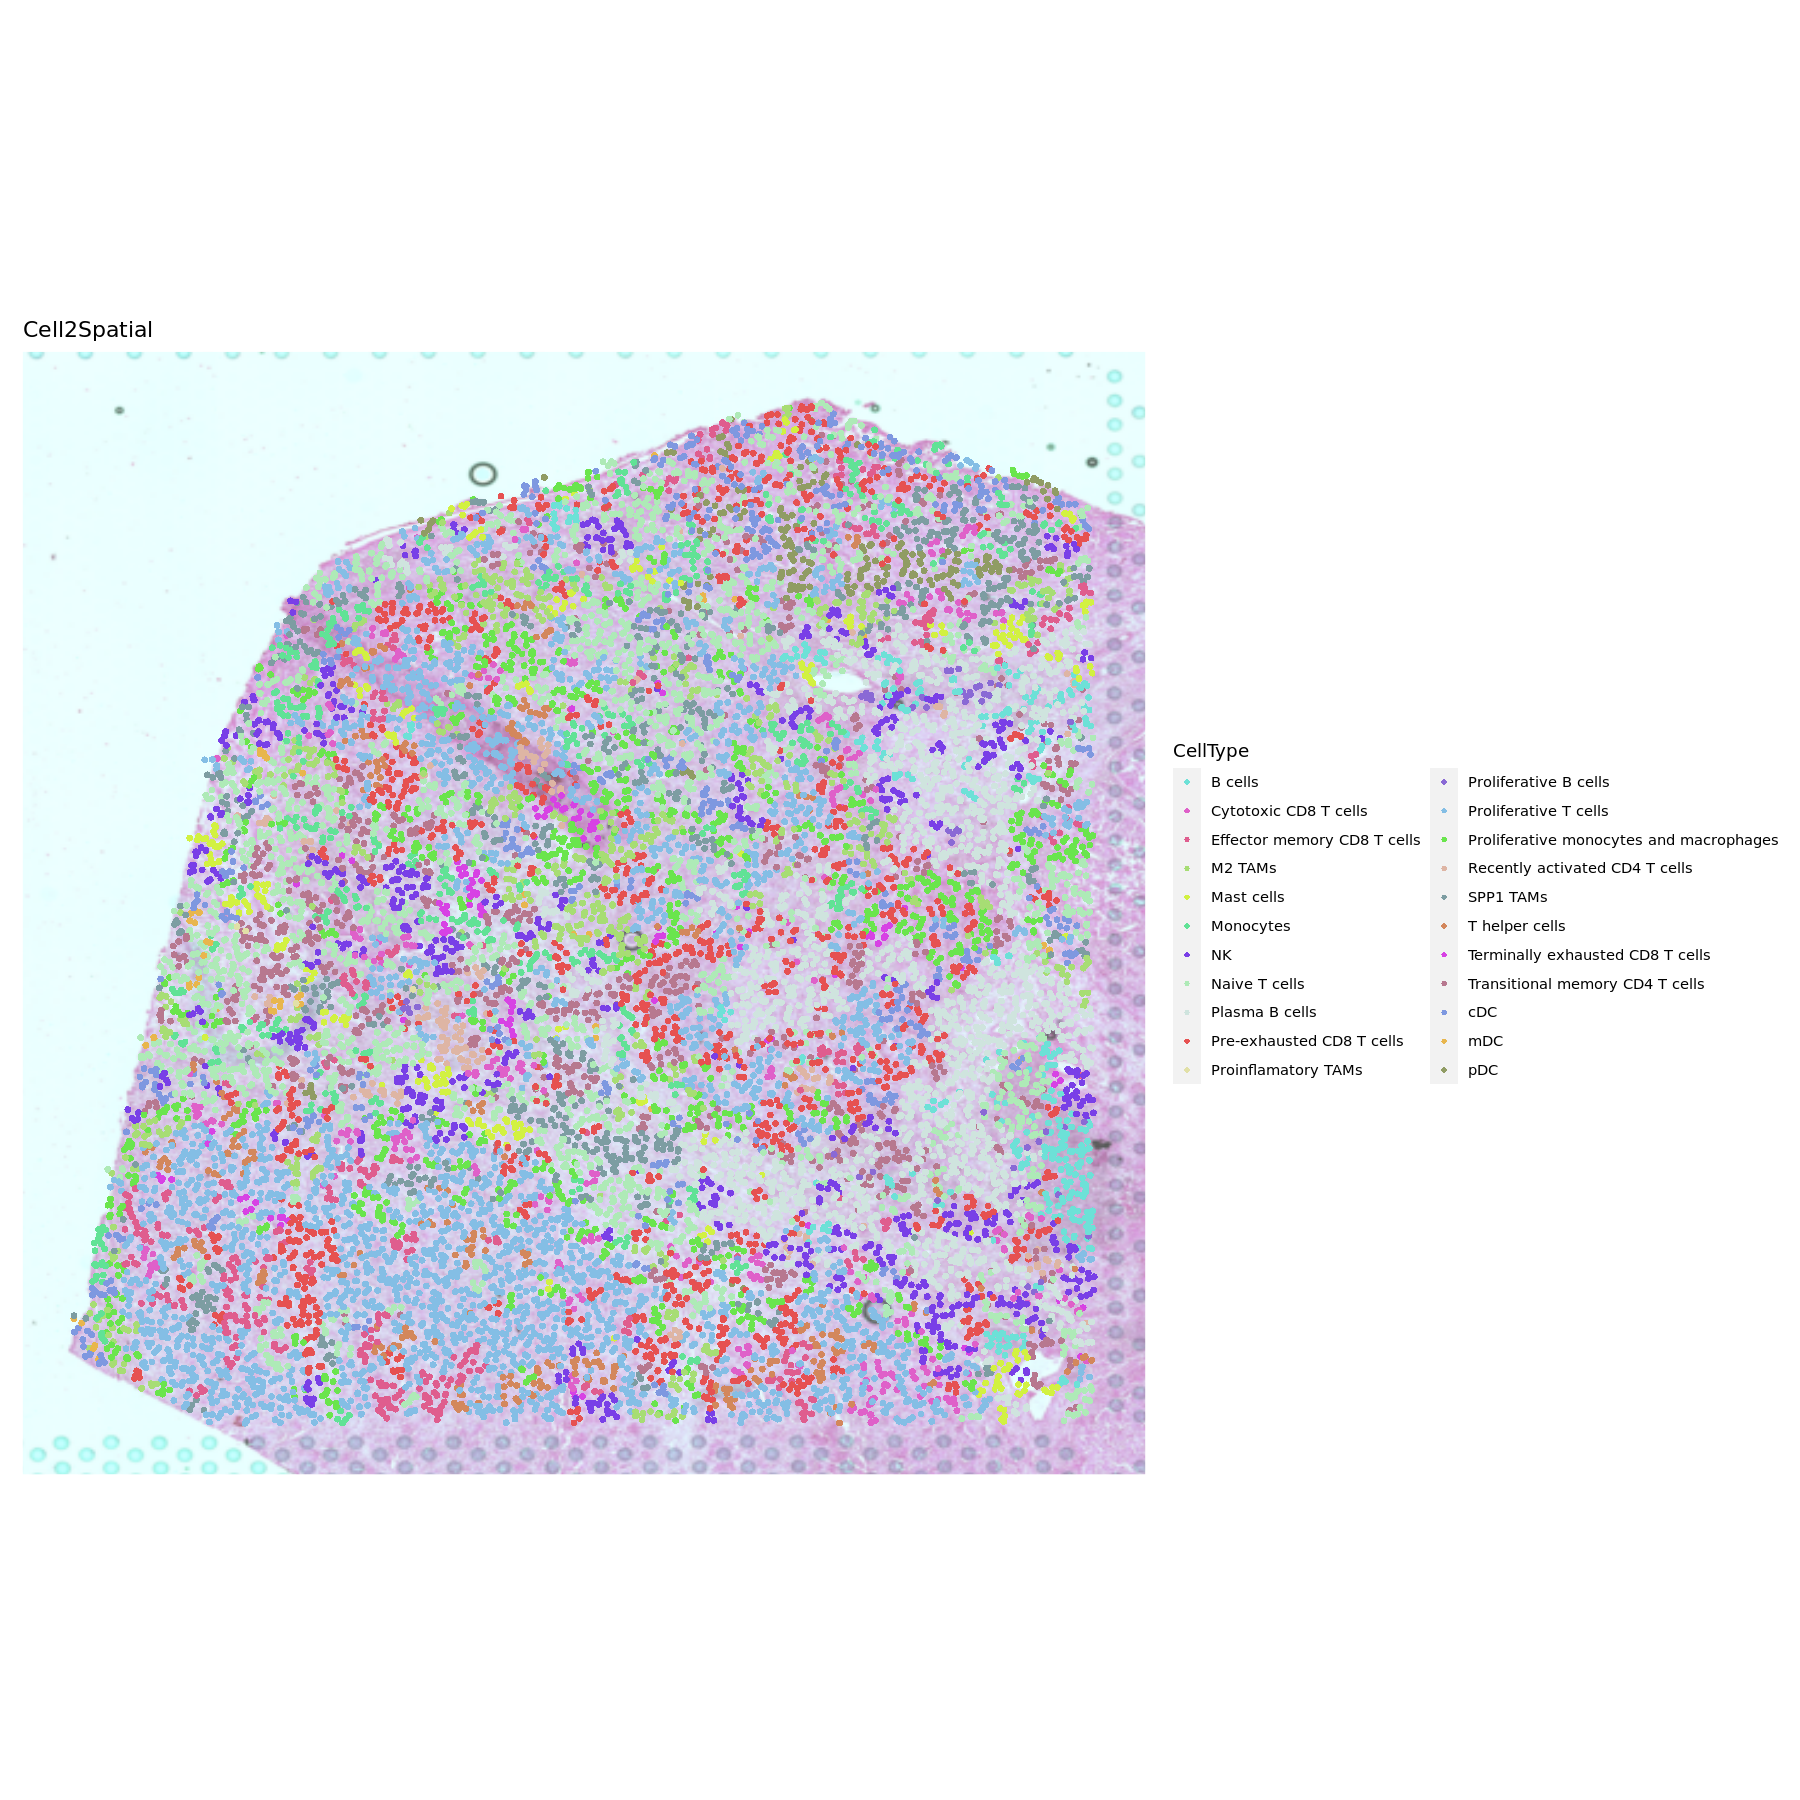

In [495]:
options(repr.plot.width = 15, repr.plot.height = 15)
SpatialDimPlot(cell2spatial, group.by = 'CellType', pt.size = 0.6, image.alpha = 0.7, stroke = NA, cols = cell.colors) + ggtitle('Cell2Spatial')
ggsave(file.path(out.figs.dir, 'cell2spatial.entire.UMAP.pdf'), width = 10, height = 4)

In [499]:
f.ctypes <- cell2spatial$CellType %>% unique
gps <- lapply(f.ctypes, function(ct) {
    h.cells <- subset(cell2spatial, CellType == ct) %>% Cells
    obj.sub <- cell2spatial[, h.cells]
    SpatialDimPlot(obj.sub, image.alpha = 0.5, group.by = 'CellType',  pt.size.factor = 1, crop = FALSE, stroke = NA, cols = cell.colors[ct]) + ggtitle(ct) + NoLegend()  
})

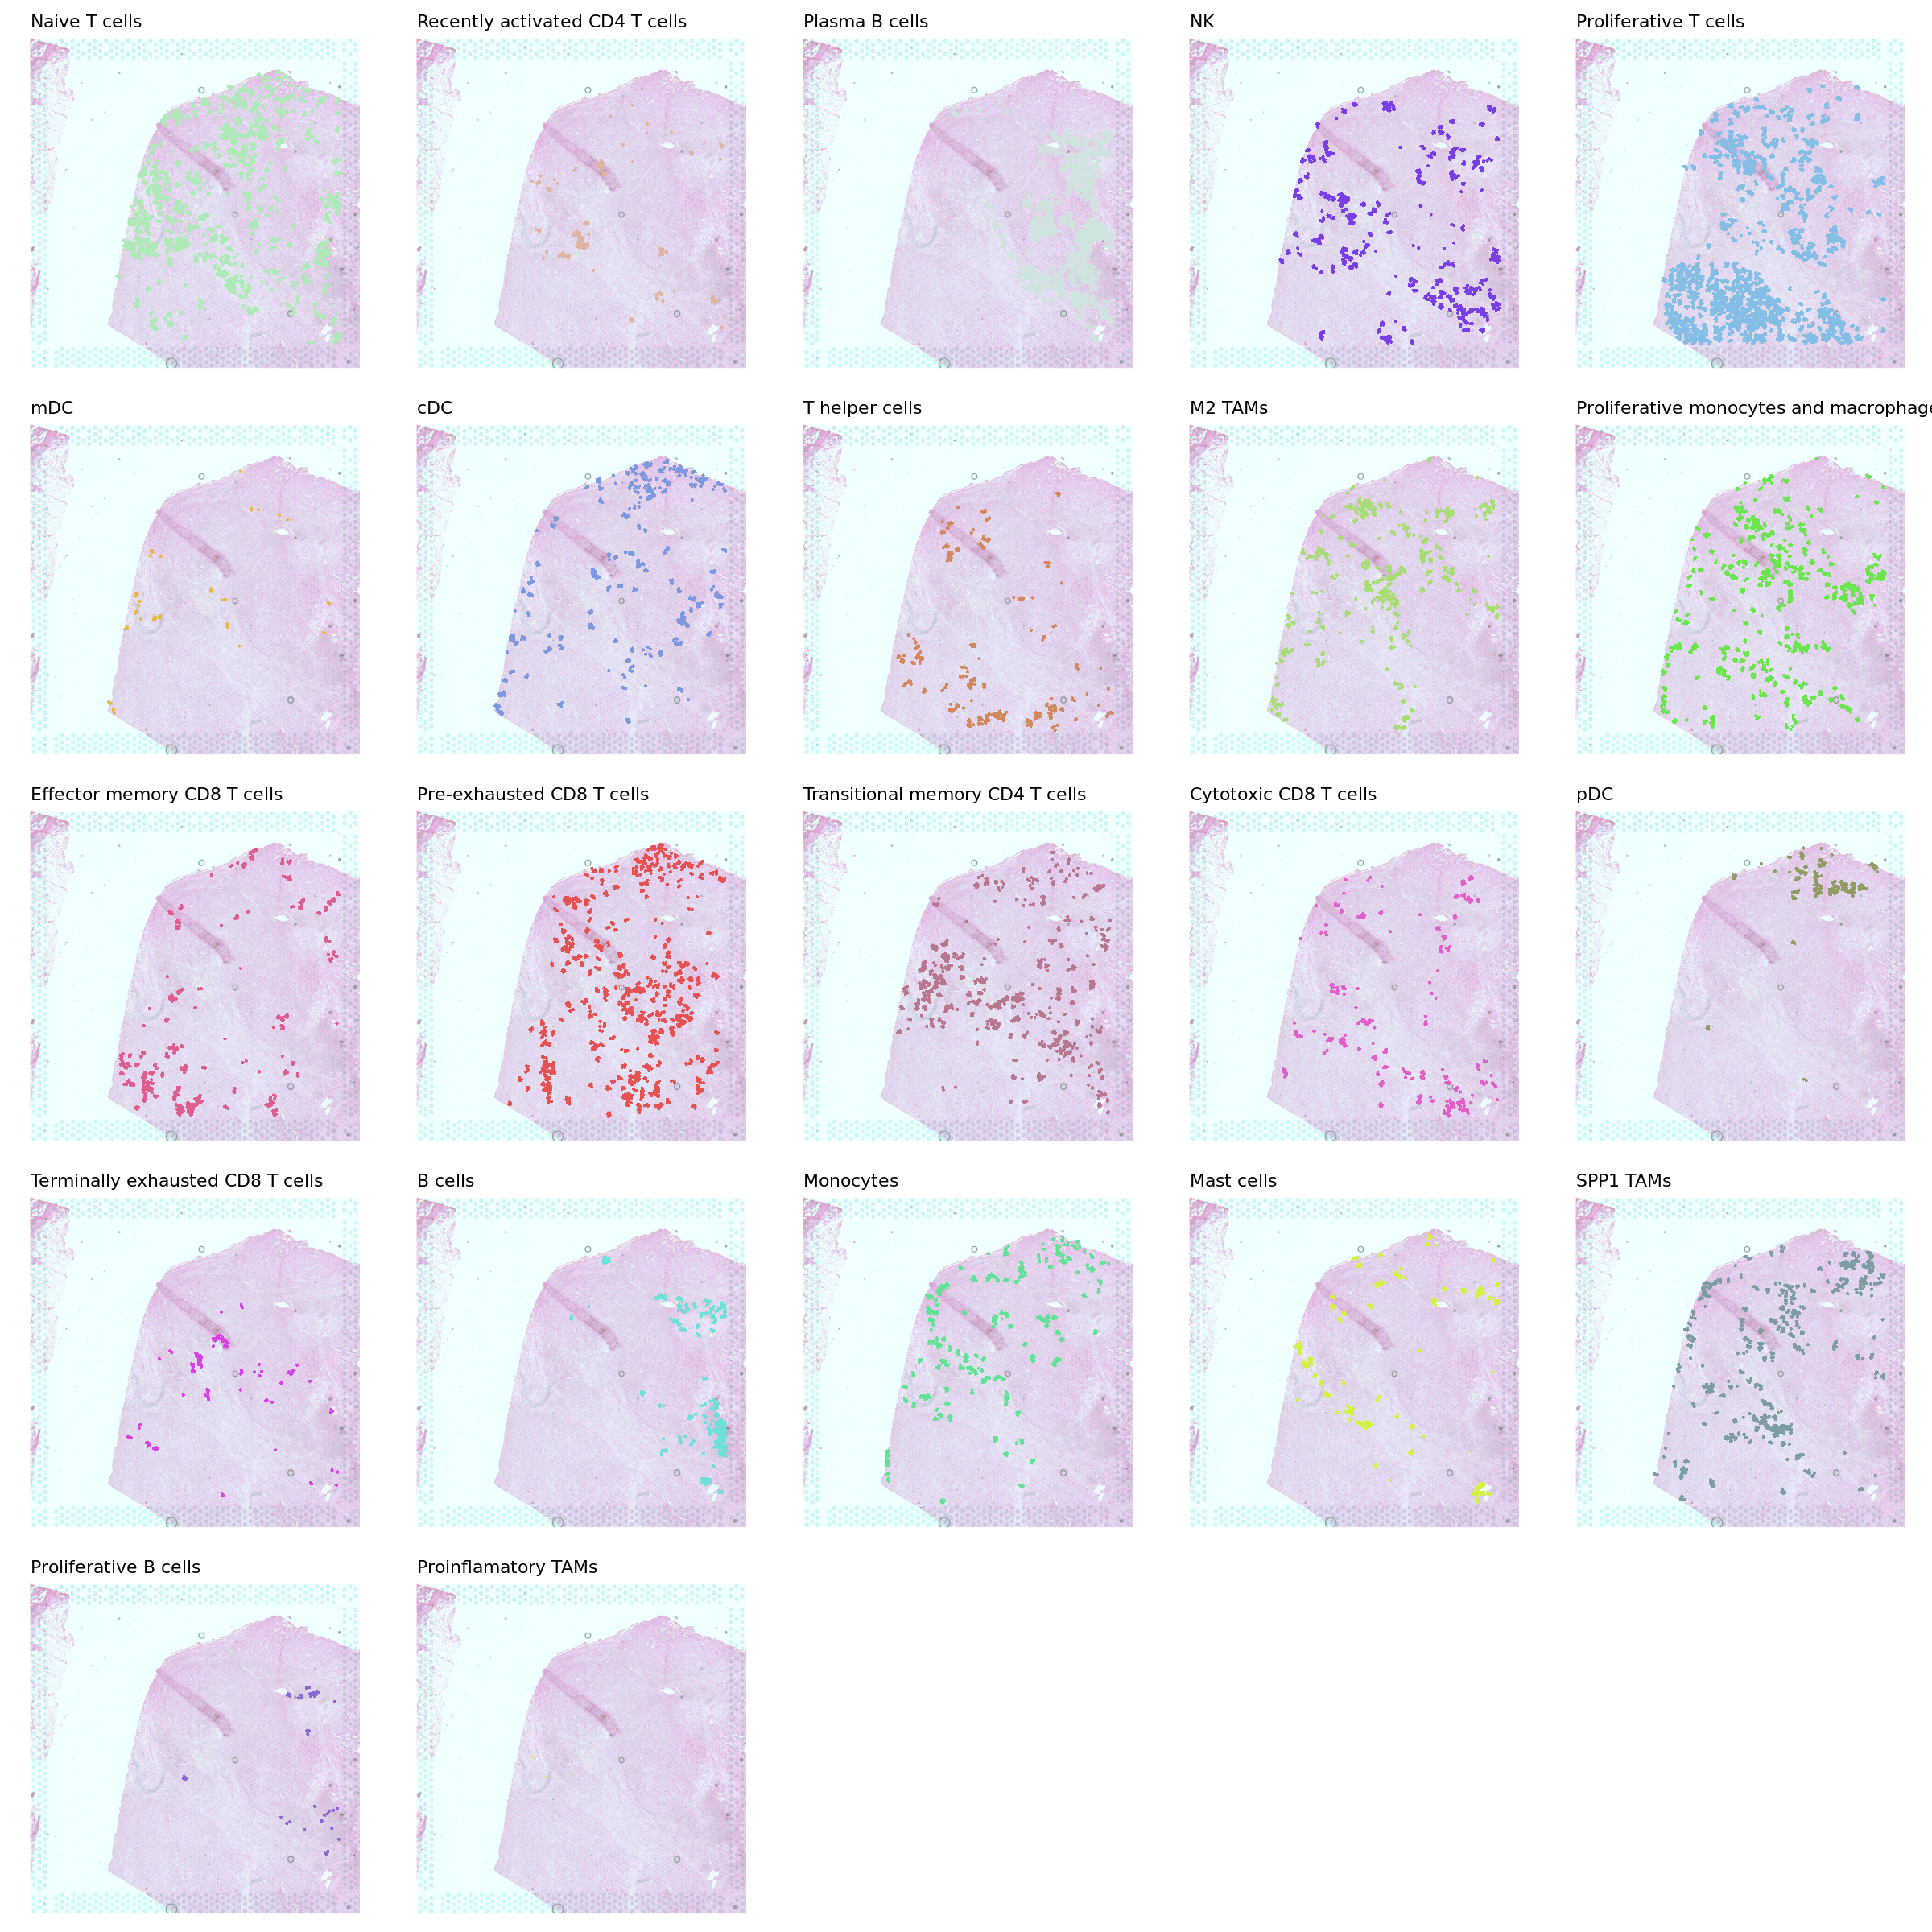

In [501]:
options(repr.plot.width = 20, repr.plot.height = 20)
ggarrange(plotlist = gps, nrow = 5, ncol = 5)
ggsave(file.path(out.figs.dir, 'cell2spatial.split.UMAP.pdf'), width = 20, height = 20)

### Cell type co-exist analysis

In [448]:
cell2spatial$TLS <- 'N'
cell2spatial$TLS[cell2spatial$SpotName %in% (subset(brain.st, TLS_2_cat == 'TLS') %>% Cells)] <- 'T'

In [450]:
saveRDS(cell2spatial, file = file.path(out.data.dir, 'for.cellchat.RDS'))

In [451]:
saveRDS(brain.st, file = file.path(out.data.dir, 'for.cellchat.st.RDS'))

In [424]:
head(cell2spatial@meta.data)

,orig.ident,nCount_Spatial,nFeature_Spatial,nCount_RNA,nFeature_RNA,patient,percent.mt,gender,source,subtype,⋯,RawName,x,y,centerSPOT,centerX,centerY,SpotName,EDwithCenter,CellType,Cell
,<fct>,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,"<dbl[,1]>",<chr>,<chr>
CCTTACGTCAGGATCT-1-D20180116_T_3,SeuratProject,960.5449,1211,2234,1212,LIV2_5,1.786393,male,liver2,HCC,⋯,CCTTACGTCAGGATCT-1-D20180116_T_3,146.4006,378.2100,143.632921875x376.61846875,143.6329,376.6185,AAACAAGTATCTCCCA-1,3.1926483,Naive T cells,CCTTACGTCAGGATCT-1-D20180116_T_3
T22_TACGGGCAGGTGCACA_15,SeuratProject,926.0018,1118,1865,1118,PAN_22,2.714493,female,pancreas,PDAC,⋯,T22_TACGGGCAGGTGCACA_15,141.4086,377.0669,143.632921875x376.61846875,143.6329,376.6185,AAACAAGTATCTCCCA-1,2.2691116,Naive T cells,T22_TACGGGCAGGTGCACA_15
T22_TACGGGCAGGTGCACA_15.1,SeuratProject,926.0018,1118,1865,1118,PAN_22,2.714493,female,pancreas,PDAC,⋯,T22_TACGGGCAGGTGCACA_15,144.1193,376.7708,143.632921875x376.61846875,143.6329,376.6185,AAACAAGTATCTCCCA-1,0.5096438,Naive T cells,T22_TACGGGCAGGTGCACA_15.1
T22_TACGGGCAGGTGCACA_15.2,SeuratProject,926.0018,1118,1865,1118,PAN_22,2.714493,female,pancreas,PDAC,⋯,T22_TACGGGCAGGTGCACA_15,144.1352,374.8733,143.632921875x376.61846875,143.6329,376.6185,AAACAAGTATCTCCCA-1,1.8160171,Naive T cells,T22_TACGGGCAGGTGCACA_15.2
T22_TACGGGCAGGTGCACA_15.3,SeuratProject,926.0018,1118,1865,1118,PAN_22,2.714493,female,pancreas,PDAC,⋯,T22_TACGGGCAGGTGCACA_15,144.3568,373.2382,143.632921875x376.61846875,143.6329,376.6185,AAACAAGTATCTCCCA-1,3.4568903,Naive T cells,T22_TACGGGCAGGTGCACA_15.3
GATGAGGTCCCTTGTG_40_2,SeuratProject,171.3933,193,932,193,SC040,1.832994,NA,colorectal,CRC,⋯,GATGAGGTCCCTTGTG_40_2,465.2028,437.2763,466.611359375x438.012828125,466.6114,438.0128,AAACACCAATAACTGC-1,1.5894966,Recently activated CD4 T cells,GATGAGGTCCCTTGTG_40_2


In [425]:
coexist.lst <- lapply(levels(brain.st), function(idx) {
    cells <- subset(brain.st, idents = idx) %>% Cells
    obj.sub <- subset(cell2spatial, SpotName %in% cells)
    co.index <- coExistIndex(obj.sub)   
})

In [329]:
cells <- subset(brain.st, TLS_2_cat == 'TLS') %>% Cells

In [330]:
obj.sub <- subset(cell2spatial, SpotName %in% cells)

In [331]:
table(obj.sub$CellType)


                         B cells            Cytotoxic CD8 T cells 
                             201                               30 
     Effector memory CD8 T cells                          M2 TAMs 
                               6                                5 
                      Mast cells                               NK 
                              11                              158 
                   Naive T cells                   Plasma B cells 
                             138                              506 
       Pre-exhausted CD8 T cells            Proliferative B cells 
                              58                               31 
           Proliferative T cells   Recently activated CD4 T cells 
                               5                               13 
                       SPP1 TAMs                   T helper cells 
                               2                                7 
Terminally exhausted CD8 T cells  Transitional memory CD4 T c

In [413]:
co.index <- coExistIndex(cell2spatial)

In [415]:
#plotCoexistCtypes(co.index, plot.type = 'network')
saveRDS(co.index, file.path(out.data.dir, 'co.index.RDS'))
saveRDS(cell.colors, file.path(out.data.dir, 'cell.colors.RDS'))

In [452]:
pdf(file.path(out.figs.dir, 'heatmap.coexist.pdf'), width = 8, height = 8)
heatmap(co.index)
dev.off()

png 
  2

In [454]:
cells <- subset(brain.st, idents = '4') %>% Cells
obj.sub <- subset(cell2spatial, SpotName %in% cells)

In [456]:
obj.sub <- subset(obj.sub, TLS == 'T')
obj.sub

An object of class Seurat 
15157 features across 1075 samples within 1 assay 
Active assay: Spatial (15157 features, 0 variable features)
 1 image present: slice1

In [490]:
pseud.coord <- obj.sub@meta.data
#pseud.coord <- subset(pseud.coord, CellType== 'Plasma B cells')

In [491]:
projCellTypeToSpatial <- function(pseud.coord, obj = NULL, title = NULL, size = 0.3, shape = 21) {
    idxes <- which(!duplicated(pseud.coord$CellType))
    pseud.coord$Label <- ''
    pseud.coord$Label[idxes] <- pseud.coord$CellType[idxes]
    g1 <- ggplot(pseud.coord, aes(x = y, y = x, fill = CellType)) +
        geom_point(size = size, shape = shape) +
        ggrepel::geom_text_repel(data = subset(pseud.coord, Label != ''), aes(label = Label), color = 'white', box.padding = 1.2, size = 6)  +
        ggplot2::scale_y_reverse() +
        theme_bw() +
        theme(
            panel.background = element_rect(fill = "black"),
            panel.border = element_blank(),
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.ticks = element_blank(),
            axis.text = element_blank(),
            plot.title = element_text(hjust = 0.5)

        ) + ylab('') + xlab('') +
        scale_fill_manual(values = cell.colors) +

        guides(colour = guide_legend(override.aes = list(size = 4)))
    return(g1)
}


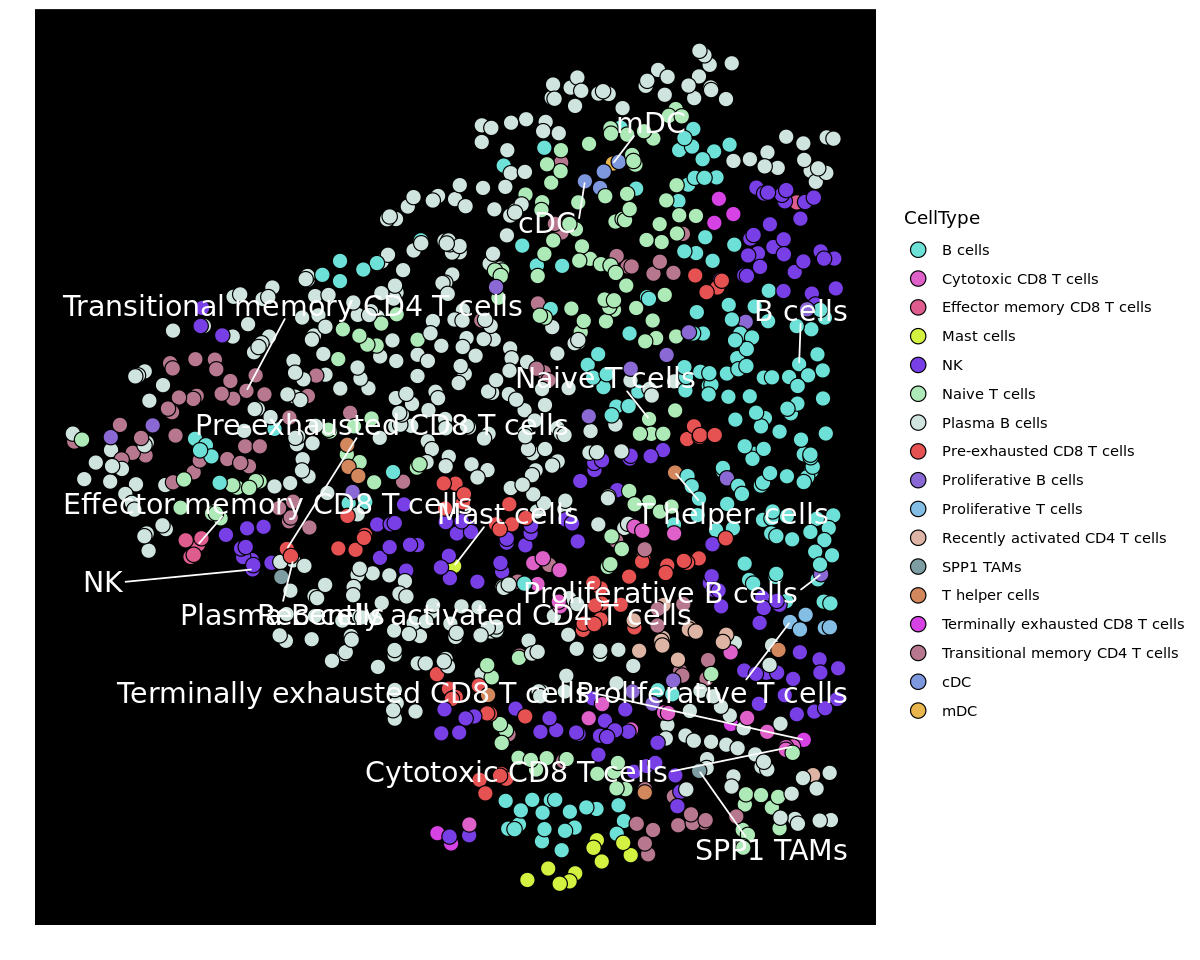

In [493]:
options(repr.plot.width = 10, repr.plot.height = 8)
projCellTypeToSpatial(pseud.coord, size = 4, shape = 21)
ggsave(file.path(out.figs.dir, 'enlarge.tls.region.pdf'), width = 10, height = 8)

In [453]:
sessionInfo()

R version 4.1.2 (2021-11-01)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 22.04.2 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/blas/libblas.so.3.10.0
LAPACK: /usr/lib/x86_64-linux-gnu/lapack/liblapack.so.3.10.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

attached base packages:
[1] splines   stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] Cell2Spatial_1.0.0  viridis_0.6.4       viridisLite_0.4.2  
 [4] monocle_2.22.0      DDRTree_0.1.5       irlba_2.3.5.1      
 [7] VGAM_1.1-9          Matrix_1.6-0        CARD_1.1           
[10] Biobase_2.54.0      BiocGenerics_0.40.0 CellTrek_0.0.94    
[13] tidydr_0.0.5        ggpubr_0.6.0        stringr_1.5.0      
[16] reticu